In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [2]:
df = pd.read_excel("/content/Real estate valuation data set.xlsx") # after extracting zip


In [3]:

print(df.head())
print(df.info())
print(df.describe())


   No  X1 transaction date  X2 house age  \
0   1          2012.916667          32.0   
1   2          2012.916667          19.5   
2   3          2013.583333          13.3   
3   4          2013.500000          13.3   
4   5          2012.833333           5.0   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   

   X5 latitude  X6 longitude  Y house price of unit area  
0     24.98298     121.54024                        37.9  
1     24.98034     121.53951                        42.2  
2     24.98746     121.54391                        47.3  
3     24.98746     121.54391  

In [24]:

#df = df.drop(columns=['No'])

x = df.drop(columns=['Y house price of unit area'])
y = df['Y house price of unit area']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [25]:
# 4. Build model
model = LinearRegression()
model.fit(x_train, y_train)


LinearRegression()

In [26]:
# 5. Prediction
y_pred = model.predict(x_test)
# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 5.305232952584752
MSE: 53.502252361179515
RMSE: 7.314523385783897
R2 Score: 0.6810781244679265


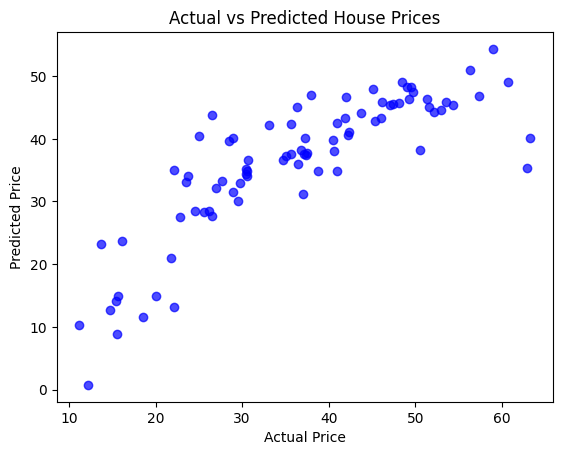

In [27]:
# 6. Visualization
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()